In [5]:
!pip install torch torchvision matplotlib pillow

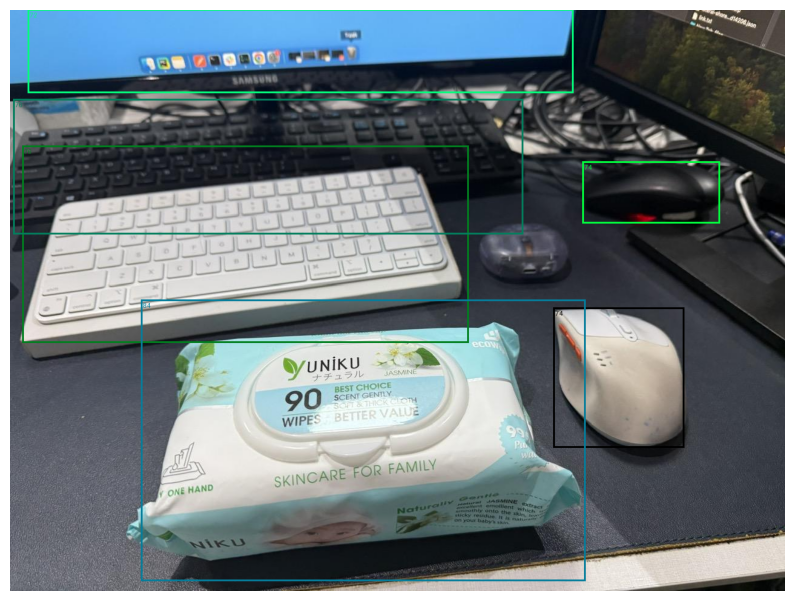

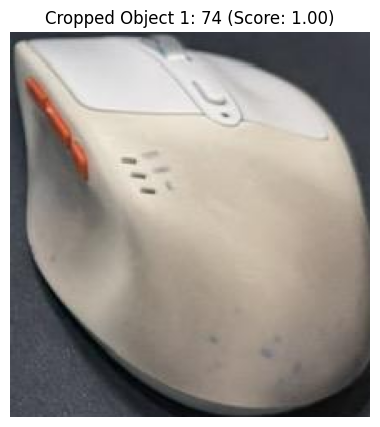

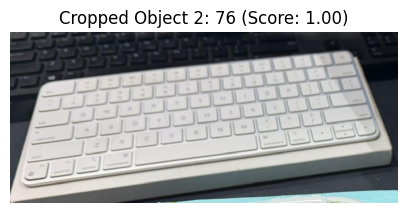

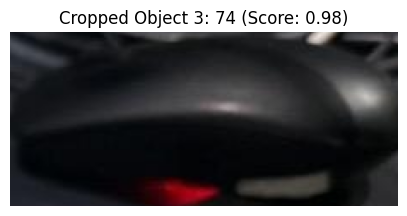

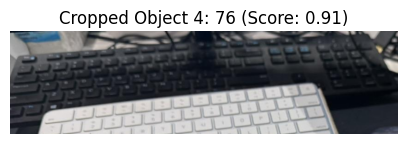

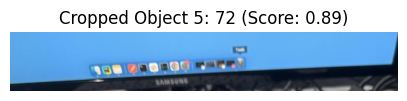

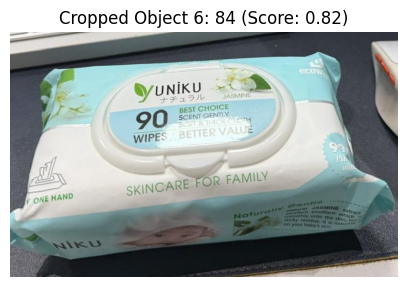

In [16]:
# Import necessary libraries
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt
from PIL import Image

# Load a pre-trained Faster R-CNN model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.to(device)
model.eval()  # Set the model to evaluation mode

# Function to load and transform an image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([transforms.ToTensor()])
    return transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

# Function to perform object detection
def detect_objects(image_tensor):
    with torch.no_grad():
        predictions = model(image_tensor)
    return predictions

# Function to visualize and show cropped objects excluding humans with labels and scores
def visualize_and_show_crops(image_path, predictions, threshold=0.8):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transforms.ToTensor()(image)

    # Filter boxes and labels based on the threshold
    keep = predictions[0]['scores'] > threshold
    boxes = predictions[0]['boxes'][keep]
    labels = predictions[0]['labels'][keep].cpu()  # Move labels to CPU for processing
    scores = predictions[0]['scores'][keep].cpu()  # Move scores to CPU for processing

    # Exclude humans (label index 1)
    non_human_indices = (labels != 1)
    boxes = boxes[non_human_indices]
    labels = labels[non_human_indices]
    scores = scores[non_human_indices]

    # Convert labels to string for display
    labels = [str(label.item()) for label in labels]  # Convert to string format

    # Draw bounding boxes on the image
    draw_boxes = draw_bounding_boxes(image_tensor, boxes, labels, width=3)

    plt.figure(figsize=(10, 10))
    plt.imshow(draw_boxes.permute(1, 2, 0))  # Change dimensions for display
    plt.axis('off')
    plt.show()

    # Show cropped objects with labels and scores
    for i, box in enumerate(boxes):
        x_min, y_min, x_max, y_max = box.int()
        cropped_object = image.crop((x_min.item(), y_min.item(), x_max.item(), y_max.item()))

        plt.figure(figsize=(5, 5))
        plt.imshow(cropped_object)
        plt.title(f'Cropped Object {i+1}: {labels[i]} (Score: {scores[i]:.2f})')
        plt.axis('off')
        plt.show()

# Example usage
image_path = 'img_test_16.jpg'  # Replace with your image path
image_tensor = load_image(image_path)
predictions = detect_objects(image_tensor)
visualize_and_show_crops(image_path, predictions)